In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

In [83]:
P_R=pd.read_csv('patient_records.csv')
P_R.head(2)

,patient_id,first_name,last_name,gender,age,blood_type,state,smoking_status,insurance_type,primary_condition,height_cm,weight_kg,systolic_bp,diastolic_bp,heart_rate_bpm,last_admission_date
0,PT100000,Sarah,Jackson,Male,0,O+,CA,Former,Private,Type 2 Diabetes,152.3,81.8,71,58,75,2024-07-19
1,PT100001,Jessica,Smith,Female,53,O+,PA,Former,Medicaid,Anxiety Disorder,183.2,45.6,114,89,75,2025-01-16


In [12]:
df = pd.read_csv('patient_records.csv', usecols=['age', 'height_cm'])
df

,age,height_cm
0,0,152.3
1,53,183.2
2,70,178.1
3,52,171.5
4,36,169.7
...,...,...
1195,27,177.1
1196,32,175.9
1197,52,171.0
1198,27,175.2


In [13]:
df.isnull().sum()

age           0
height_cm    53
dtype: int64

In [16]:
df['height_cm']=df['height_cm'].fillna(df['height_cm'].mean(), inplace=True)
df['height_cm']

C:\Users\lands\AppData\Local\Temp\ipykernel_23580\3379864041.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['height_cm']=df['height_cm'].fillna(df['height_cm'].mean(), inplace=True)


0       152.3
1       183.2
2       178.1
3       171.5
4       169.7
        ...  
1195    177.1
1196    175.9
1197    171.0
1198    175.2
1199    181.7
Name: height_cm, Length: 1200, dtype: float64

In [17]:
df.isnull().sum()

age          0
height_cm    0
dtype: int64

In [18]:
X=df
X

,age,height_cm
0,0,152.3
1,53,183.2
2,70,178.1
3,52,171.5
4,36,169.7
...,...,...
1195,27,177.1
1196,32,175.9
1197,52,171.0
1198,27,175.2


In [20]:
Y=P_R['heart_rate_bpm']
Y

0        75
1        75
2        66
3        99
4        72
       ... 
1195     87
1196    102
1197     66
1198     94
1199     94
Name: heart_rate_bpm, Length: 1200, dtype: int64

In [40]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.3)
X_train

,age,height_cm
183,62,156.3
459,42,200.3
1028,74,165.3
1171,79,165.2
339,32,177.5
...,...,...
755,80,177.9
778,20,174.4
381,88,166.6
354,94,178.8


In [41]:
X_test

,age,height_cm
906,26,163.6
777,28,155.9
163,38,176.6
744,72,166.2
776,58,147.1
...,...,...
680,41,174.5
221,37,157.7
554,26,163.3
665,52,174.7


In [22]:
Y_train

222     82
884     90
191     65
923     68
322     76
        ..
1031    71
806     64
123     98
1038    52
494     75
Name: heart_rate_bpm, Length: 840, dtype: int64

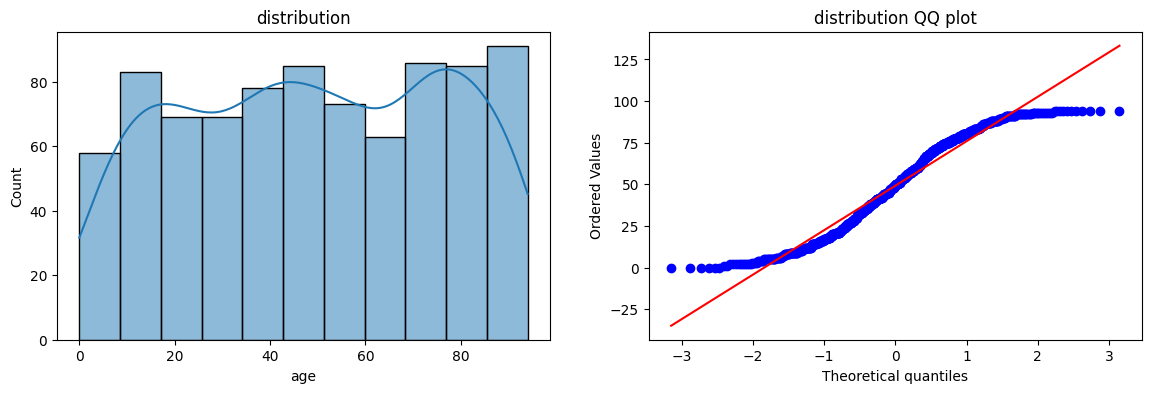

In [26]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['age'], kde=True)

plt.title('distribution')


plt.subplot(122)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('distribution QQ plot')

plt.show()

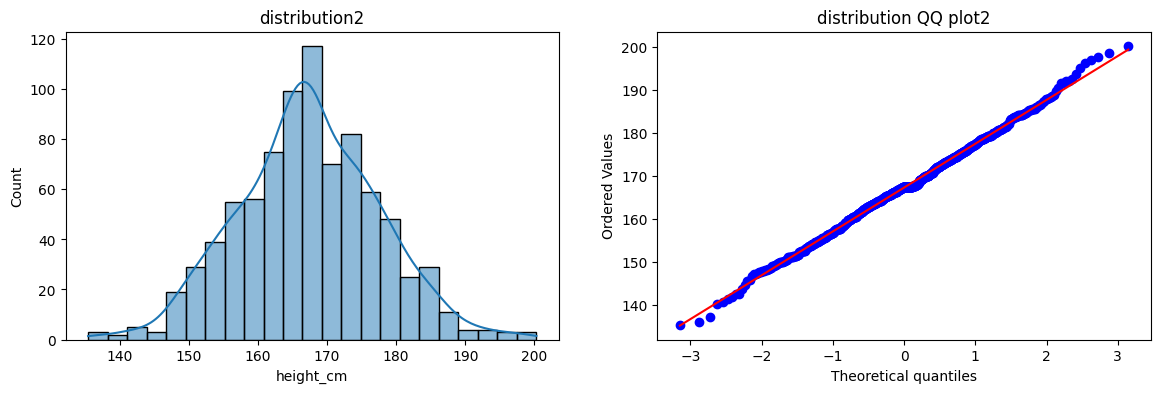

In [27]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['height_cm'], kde=True)

plt.title('distribution2')


plt.subplot(122)
stats.probplot(X_train['height_cm'], dist="norm", plot=plt)
plt.title('distribution QQ plot2')

plt.show()

In [28]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [33]:
clf.fit(X_train, Y_train)

C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [34]:
clf2.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
print(type(X_train), X_train.shape)
print(type(X_test), X_test.shape)

<class 'pandas.DataFrame'> (840, 2)
<class 'pandas.Series'> (360,)


In [42]:
Y_pred=clf.predict(X_test)
Y_pred

array([79, 79, 79, 77, 77, 79, 77, 79, 79, 81, 77, 81, 77, 77, 77, 79, 79,
       79, 77, 77, 79, 77, 77, 77, 77, 79, 79, 77, 79, 77, 77, 79, 79, 77,
       81, 77, 79, 81, 81, 79, 77, 79, 81, 79, 77, 77, 79, 77, 77, 77, 79,
       77, 81, 79, 77, 81, 77, 81, 79, 79, 77, 79, 77, 81, 81, 81, 77, 79,
       79, 79, 79, 79, 77, 79, 81, 81, 77, 81, 77, 81, 77, 79, 79, 77, 81,
       81, 77, 79, 79, 79, 77, 79, 77, 79, 79, 77, 77, 77, 79, 81, 79, 79,
       81, 81, 79, 79, 77, 79, 81, 77, 77, 79, 81, 79, 81, 79, 79, 77, 81,
       77, 77, 79, 79, 79, 77, 81, 81, 79, 79, 81, 79, 79, 79, 79, 79, 77,
       77, 77, 81, 79, 77, 79, 77, 79, 79, 81, 79, 77, 77, 77, 79, 79, 79,
       77, 79, 79, 79, 77, 79, 77, 81, 79, 77, 81, 81, 79, 77, 79, 81, 77,
       79, 81, 79, 77, 81, 79, 81, 79, 79, 77, 79, 79, 77, 79, 79, 77, 81,
       79, 81, 79, 77, 79, 77, 79, 77, 79, 79, 77, 79, 79, 79, 79, 77, 79,
       81, 77, 77, 79, 79, 79, 79, 79, 79, 77, 79, 79, 77, 79, 79, 77, 81,
       79, 79, 79, 79, 79

In [43]:
Y_pred_clf2=clf2.predict(X_test)
Y_pred_clf2

array([ 68,  82,  74,  74, 101,  74,  79,  77,  86,  50,  76,  64,  73,
        58,  80,  74,  75,  93,  82,  70,  65,  85,  73,  68,  74,  98,
        67,  69,  66,  85,  67,  90, 103, 104,  81,  75,  97,  73,  84,
        78,  59,  78,  44,  88,  88,  75,  65,  67,  74,  87,  71,  77,
        98,  65,  82,  84,  87,  68,  69,  86,  77,  67,  88,  71,  98,
        76,  77,  28,  79,  86,  73,  78,  91,  69,  83,  76,  91,  80,
        98,  83,  64,  69,  82,  67,  52,  60,  79,  88,  70,  71,  69,
        66,  81,  76,  65,  72,  68,  80,  67,  80,  80,  77,  81,  55,
       101,  79,  85,  74,  87, 105,  82,  82,  95,  62,  77,  85,  74,
        63,  89,  66,  97,  75,  77,  91,  74,  68, 102,  79,  47, 104,
        66,  77,  75,  93,  76, 101,  75,  76, 103,  73,  74,  69,  98,
        84,  80,  80, 101,  92,  87,  79,  93,  57,  83,  68,  71,  74,
        79,  76,  78,  82,  44,  78,  73,  50,  80,  49,  79,  72,  75,
        78,  66,  56,  73,  63,  79,  70,  68,  92,  86,  63,  7

In [47]:
print("Acuracy_LR", accuracy_score(Y_test, Y_pred))
print("Acuracy_DTC", accuracy_score(Y_test, Y_pred_clf2))

Acuracy_LR 0.03888888888888889
Acuracy_DTC 0.7055555555555556


##  applying log transformer

In [48]:
trf = FunctionTransformer(func=np.log1p)

In [49]:
X_train_Log_T = trf.fit_transform(X_train)
X_test_Log_T = trf.transform(X_test)

In [50]:
clf_1 = LogisticRegression()
clf_2 = DecisionTreeClassifier()

In [52]:
clf_1.fit(X_train_Log_T, Y_train)


C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [53]:
clf_2.fit(X_train_Log_T, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
Y_pred_LT = clf_1.predict(X_test)
Y_pred_LT

array([81, 81, 81, 78, 78, 81, 78, 81, 78, 81, 78, 81, 78, 78, 78, 81, 81,
       81, 78, 78, 81, 78, 78, 78, 78, 81, 81, 78, 81, 78, 78, 81, 81, 78,
       81, 78, 81, 81, 81, 81, 78, 78, 81, 78, 78, 78, 78, 78, 78, 78, 78,
       78, 81, 81, 78, 81, 78, 81, 81, 81, 78, 78, 78, 81, 81, 81, 78, 81,
       81, 78, 81, 81, 78, 78, 81, 81, 78, 81, 78, 81, 78, 81, 81, 78, 81,
       81, 78, 81, 81, 81, 78, 81, 78, 81, 81, 78, 78, 78, 81, 81, 81, 81,
       81, 81, 78, 81, 78, 78, 81, 78, 78, 81, 81, 81, 81, 81, 78, 78, 81,
       78, 78, 78, 81, 81, 78, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 78,
       78, 78, 81, 81, 78, 81, 78, 81, 81, 81, 78, 78, 78, 78, 81, 81, 81,
       78, 81, 81, 81, 78, 78, 78, 81, 81, 78, 81, 81, 78, 78, 78, 81, 78,
       81, 81, 81, 78, 81, 81, 81, 81, 81, 78, 81, 81, 78, 81, 81, 78, 81,
       81, 81, 81, 78, 81, 78, 78, 78, 81, 81, 78, 81, 78, 81, 81, 78, 81,
       81, 78, 78, 78, 81, 81, 81, 81, 81, 78, 81, 81, 78, 81, 81, 78, 81,
       81, 81, 81, 78, 81

In [56]:
Y_pred_LT2 = clf_2.predict(X_test)
Y_pred_LT2

array([77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 71, 77, 77, 77, 77, 87, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 71, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 71, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       71, 77, 77, 77, 77, 77, 77, 77, 77, 77, 71, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 87, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 71, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 71, 77, 77, 77, 71, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77

In [59]:
print("Acuracy_LR_LT", accuracy_score(Y_test, Y_pred_LT))
print("Acuracy_DTC_LT", accuracy_score(Y_test, Y_pred_LT2))

Acuracy_LR_LT 0.016666666666666666
Acuracy_DTC_LT 0.044444444444444446


## cross validation

In [65]:
X_transformed = trf.fit_transform(X)

In [68]:
clf_3 = LogisticRegression()
clf_4 = DecisionTreeClassifier()

print("Acuracy_CV_LR", np.mean(cross_val_score(clf_3, X_transformed, Y, scoring='accuracy', cv=5)))
print("Acuracy_CV_DTC", np.mean(cross_val_score(clf_4, X_transformed, Y, scoring='accuracy', cv=5)))

C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):

Acuracy_CV_LR 0.03333333333333333
Acuracy_CV_DTC 0.02583333333333333


C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/mod

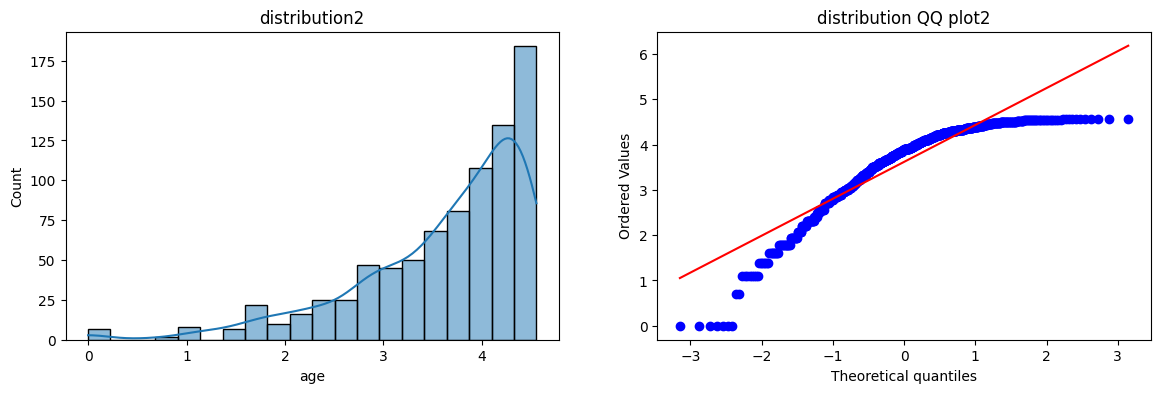

In [70]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train_Log_T['age'], kde=True)

plt.title('distribution2')


plt.subplot(122)
stats.probplot(X_train_Log_T['age'], dist="norm", plot=plt)
plt.title('distribution QQ plot2')

plt.show()

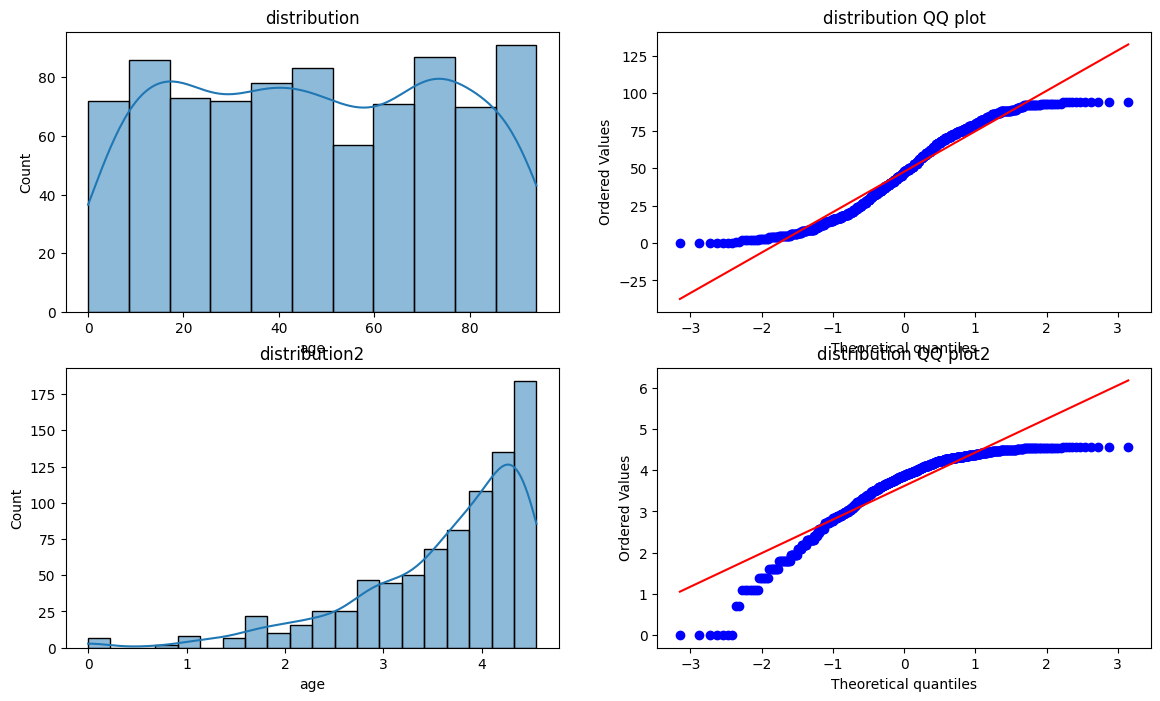

In [73]:
plt.figure(figsize=(14,8))
plt.subplot(221)
sns.histplot(X_train['age'], kde=True)

plt.title('distribution')


plt.subplot(222)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('distribution QQ plot')

plt.subplot(223)
sns.histplot(X_train_Log_T['age'], kde=True)

plt.title('distribution2')


plt.subplot(224)
stats.probplot(X_train_Log_T['age'], dist="norm", plot=plt)
plt.title('distribution QQ plot2')

plt.show()

### for height 

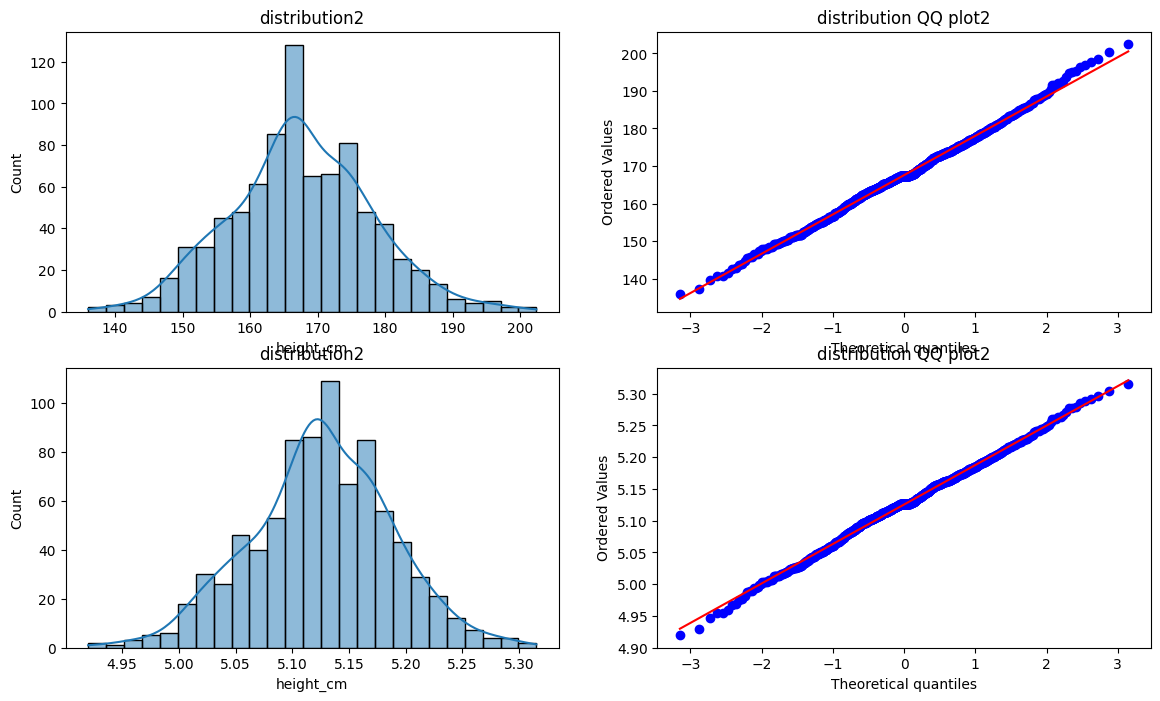

In [74]:
plt.figure(figsize=(14,8))
plt.subplot(221)
sns.histplot(X_train['height_cm'], kde=True)

plt.title('distribution2')


plt.subplot(222)
stats.probplot(X_train['height_cm'], dist="norm", plot=plt)
plt.title('distribution QQ plot2')

plt.subplot(223)
sns.histplot(X_train_Log_T['height_cm'], kde=True)

plt.title('distribution2')


plt.subplot(224)
stats.probplot(X_train_Log_T['height_cm'], dist="norm", plot=plt)
plt.title('distribution QQ plot2')

plt.show()


## now using column tranformer

In [75]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['age'])], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

In [77]:
clf_5 = LogisticRegression()
clf_6 = DecisionTreeClassifier()

clf_5.fit(X_train_transformed2, Y_train)
clf_6.fit(X_train_transformed2, Y_train)

Y_pred_a = clf_5.predict(X_test_transformed2)
Y_pred_b = clf_6.predict(X_test_transformed2)


print("Acuracy_clf_5", accuracy_score(Y_test, Y_pred_a))
print("Acuracy_clf_6", accuracy_score(Y_test, Y_pred_b))

Acuracy_clf_5 0.016666666666666666
Acuracy_clf_6 0.025


C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

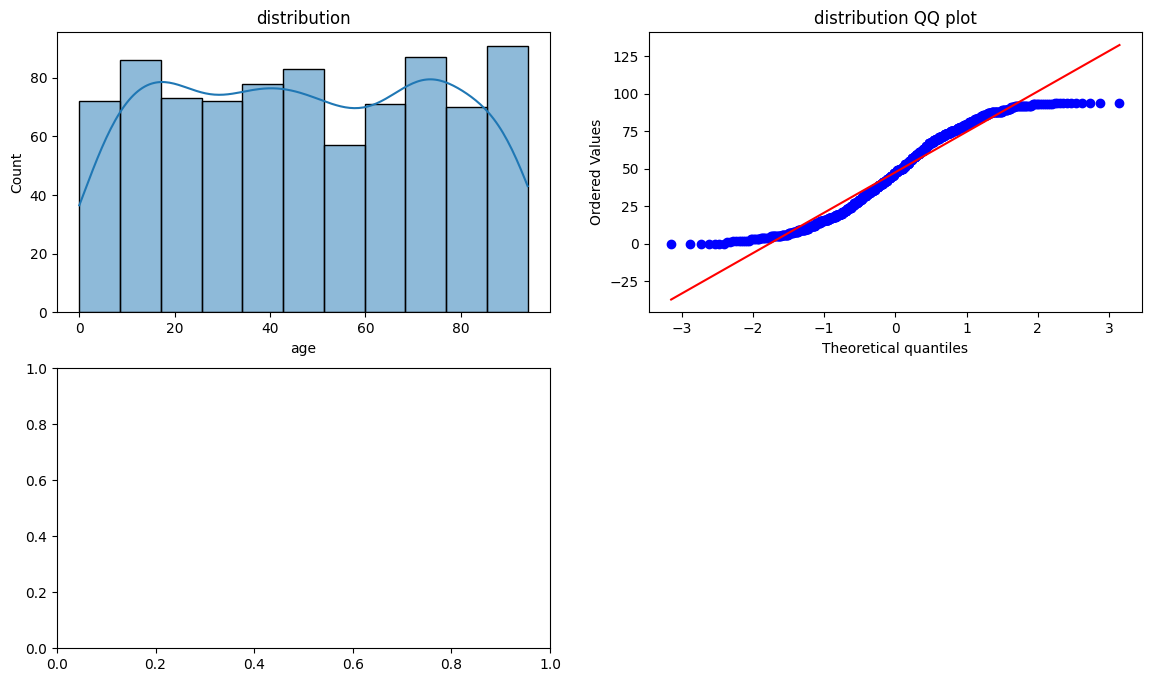

In [78]:
plt.figure(figsize=(14,8))
plt.subplot(221)
sns.histplot(X_train['age'], kde=True)

plt.title('distribution')


plt.subplot(222)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('distribution QQ plot')

plt.subplot(223)
sns.histplot(X_train_transformed2['age'], kde=True)

plt.title('distribution2')


plt.subplot(224)
stats.probplot(X_train_transformed2['age'], dist="norm", plot=plt)
plt.title('distribution QQ plot2')

plt.show()

In [104]:
P_R.isnull().sum()

patient_id              0
first_name              0
last_name               0
gender                  0
age                     0
blood_type             55
state                   0
smoking_status         52
insurance_type          0
primary_condition       5
height_cm              53
weight_kg              48
systolic_bp             0
diastolic_bp            0
heart_rate_bpm          0
last_admission_date     0
dtype: int64

In [95]:
df.isnull().sum()

age          0
height_cm    0
dtype: int64

##  making a function

In [124]:
def math_transform(transform):

    X=P_R.iloc[:,[4, 12]]
    Y=P_R.iloc[:,-2]
    
    trf = ColumnTransformer([('log', FunctionTransformer(transform), ['age'])], remainder='passthrough')
    X_trans=trf.fit_transform(X)

    clf_ = LogisticRegression()

    print('Accuracy', np.mean(cross_val_score(clf_, X_trans, Y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X['age'], dist="norm", plot=plt)
    plt.title('distribution QQ plot')
    
    
    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist="norm", plot=plt)
    plt.title('distribution QQ plot2')

    plt.show()

C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1)

Accuracy 0.04083333333333334


C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


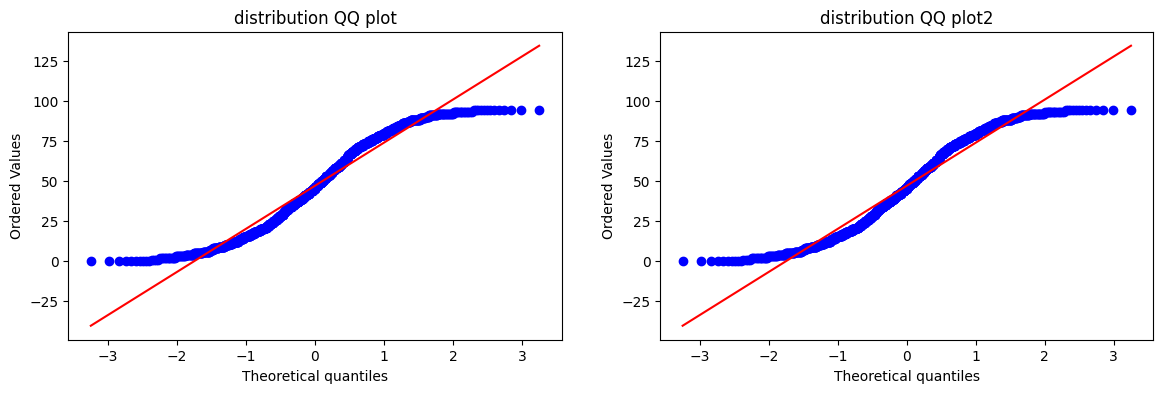

In [125]:
math_transform(lambda X:X)

In [88]:
Y=P_R.iloc[:,-2]
Y   

0        75
1        75
2        66
3        99
4        72
       ... 
1195     87
1196    102
1197     66
1198     94
1199     94
Name: heart_rate_bpm, Length: 1200, dtype: int64

In [111]:
print(P_R.columns.tolist())
print(P_R.iloc[:, -2].nunique())
print(P_R.iloc[:, -2].head())

['patient_id', 'first_name', 'last_name', 'gender', 'age', 'blood_type', 'state', 'smoking_status', 'insurance_type', 'primary_condition', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'heart_rate_bpm', 'last_admission_date']
71
0    75
1    75
2    66
3    99
4    72
Name: heart_rate_bpm, dtype: int64
